# BLACK FRIDAY (EDA AND FEATURE ENG.)

### Problem Statement
A retail compnay wants to understand the customer purchase behaviour (specifically,purchase amount) against various products of diffrent categories.they have shared purchase summary of various customers for selected high volume products from last month. The data set also contains customer demographics(gender,age,marital status,City_type,,stay_in_current_city),product details(product_id and product category)and Total purchase_amount from last month.

Now they want to build  a model to predict the purchase amount of customer against various products which will help them to create personalized offer for customer against diffrent product.

## Dataset Overview

The dataset represents transactional purchase data from a retail company collected over a specific period. 
Each row corresponds to a single product purchased by a customer and contains customer demographics, 
product-related attributes, and the total purchase amount.

The dataset is primarily used to analyze customer purchasing behavior and to build a predictive model 
for estimating purchase amount based on customer and product characteristics.

### Key Characteristics
- **Target Variable**: `Purchase`
- **Number of Records**: Large-scale dataset (customer-product level transactions)
- **Data Nature**: Structured, tabular data

### IMPORT LIBRAIRES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Import Train Dataset

In [3]:
df_train=pd.read_csv('train.csv')
df_train.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


### Import Test Dataset

In [4]:
df_test=pd.read_csv('test.csv')
df_test.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3
0,1000004,P00128942,M,46-50,7,B,2,1,1,11.0,NaN
1,1000009,P00113442,M,26-35,17,C,0,0,3,5.0,NaN
2,1000010,P00288442,F,36-45,1,B,4+,1,5,14.0,NaN
3,1000010,P00145342,F,36-45,1,B,4+,1,4,9.0,NaN
4,1000011,P00053842,F,26-35,1,C,1,0,4,5.0,12.0


### Merge both Dataset

In [5]:
df = pd.concat([df_train, df_test], ignore_index=True)
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370.0
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200.0
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422.0
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057.0
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 783667 entries, 0 to 783666
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     783667 non-null  int64  
 1   Product_ID                  783667 non-null  object 
 2   Gender                      783667 non-null  object 
 3   Age                         783667 non-null  object 
 4   Occupation                  783667 non-null  int64  
 5   City_Category               783667 non-null  object 
 6   Stay_In_Current_City_Years  783667 non-null  object 
 7   Marital_Status              783667 non-null  int64  
 8   Product_Category_1          783667 non-null  int64  
 9   Product_Category_2          537685 non-null  float64
 10  Product_Category_3          237858 non-null  float64
 11  Purchase                    550068 non-null  float64
dtypes: float64(3), int64(4), object(5)
memory usage: 71.7+ MB


In [7]:
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,7.836670e+05,783667.000000,783667.000000,783667.000000,537685.000000,237858.000000,550068.000000
mean,1.003029e+06,8.079300,0.409777,5.366196,9.844506,12.668605,9263.968713
std,1.727267e+03,6.522206,0.491793,3.878160,5.089093,4.125510,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,2.000000,3.000000,12.000000
25%,1.001519e+06,2.000000,0.000000,1.000000,5.000000,9.000000,5823.000000
50%,1.003075e+06,7.000000,0.000000,5.000000,9.000000,14.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,15.000000,16.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,18.000000,18.000000,23961.000000


In [8]:
df.drop(['User_ID'],axis=1,inplace=True)

In [9]:
df.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370.0
1,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200.0
2,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422.0
3,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057.0
4,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969.0


### Handling Categorical features "GENDER"

In [10]:
df['Gender']=df['Gender'].map({'F':0,'M':1})

### Handling Categorical feature "AGE"

In [11]:
df['Age'].unique()

array(['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25'],
      dtype=object)

In [12]:
df['Age']=df['Age'].map({'0-17':1,'18-25':2,'26-35':3,'36-45':4,'46-50':5,'51-55':6,'55+':7})

### Handling Categorical feature "CITY CATEGORY"

In [13]:
df_city=pd.get_dummies(df['City_Category'],drop_first=True,dtype=int)

In [14]:
df=pd.concat([df,df_city],axis=1)

In [15]:
df.drop(['City_Category'],axis=1,inplace=True)

In [16]:
df.head()

,Product_ID,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,B,C
0,P00069042,0,1,10,2,0,3,NaN,NaN,8370.0,0,0
1,P00248942,0,1,10,2,0,1,6.0,14.0,15200.0,0,0
2,P00087842,0,1,10,2,0,12,NaN,NaN,1422.0,0,0
3,P00085442,0,1,10,2,0,12,14.0,NaN,1057.0,0,0
4,P00285442,1,7,16,4+,0,8,NaN,NaN,7969.0,0,1


## Missing Values

In [17]:
df.isnull().sum()

Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            245982
Product_Category_3            545809
Purchase                      233599
B                                  0
C                                  0
dtype: int64

#### Replacing missing Values with mode

Product Category 2

In [18]:
df['Product_Category_2'].unique()

array([nan,  6., 14.,  2.,  8., 15., 16., 11.,  5.,  3.,  4., 12.,  9.,
       10., 17., 13.,  7., 18.])

In [19]:
df['Product_Category_2'].value_counts()

Product_Category_2
8.0     91317
14.0    78834
2.0     70498
16.0    61687
15.0    54114
5.0     37165
4.0     36705
6.0     23575
11.0    20230
17.0    19104
13.0    15054
9.0      8177
12.0     7801
10.0     4420
3.0      4123
18.0     4027
7.0       854
Name: count, dtype: int64

In [20]:
df['Product_Category_2'].mode()[0]

8.0

In [21]:
df['Product_Category_2']=df['Product_Category_2'].fillna(df['Product_Category_2'].mode()[0])

In [22]:
df['Product_Category_2'].isnull().sum()

0

Product Category 3

In [23]:
df['Product_Category_3'].unique()

array([nan, 14., 17.,  5.,  4., 16., 15.,  8.,  9., 13.,  6., 12.,  3.,
       18., 11., 10.])

In [24]:
df['Product_Category_3'].value_counts()

Product_Category_3
16.0    46469
15.0    39968
14.0    26283
17.0    23818
5.0     23799
8.0     17861
9.0     16532
12.0    13115
13.0     7849
6.0      6888
18.0     6621
4.0      2691
11.0     2585
10.0     2501
3.0       878
Name: count, dtype: int64

In [25]:
df['Product_Category_3'].mode()[0]

16.0

In [26]:
df['Product_Category_3']=df['Product_Category_2'].fillna(df['Product_Category_2'].mode()[0])

In [27]:
df['Product_Category_3'].isnull().sum()

0

In [28]:
df.shape

(783667, 12)

In [29]:
df['Stay_In_Current_City_Years'].unique()

array(['2', '4+', '3', '1', '0'], dtype=object)

In [30]:
df['Stay_In_Current_City_Years']=df['Stay_In_Current_City_Years'].str.replace('+',' ')

## Convert OBJ into INT

In [31]:
df['Stay_In_Current_City_Years']=df['Stay_In_Current_City_Years'].astype(int)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 783667 entries, 0 to 783666
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Product_ID                  783667 non-null  object 
 1   Gender                      783667 non-null  int64  
 2   Age                         783667 non-null  int64  
 3   Occupation                  783667 non-null  int64  
 4   Stay_In_Current_City_Years  783667 non-null  int32  
 5   Marital_Status              783667 non-null  int64  
 6   Product_Category_1          783667 non-null  int64  
 7   Product_Category_2          783667 non-null  float64
 8   Product_Category_3          783667 non-null  float64
 9   Purchase                    550068 non-null  float64
 10  B                           783667 non-null  int32  
 11  C                           783667 non-null  int32  
dtypes: float64(3), int32(3), int64(5), object(1)
memory usage: 62.8+ MB


## VISUALISATION

AGE vs PURCHASE

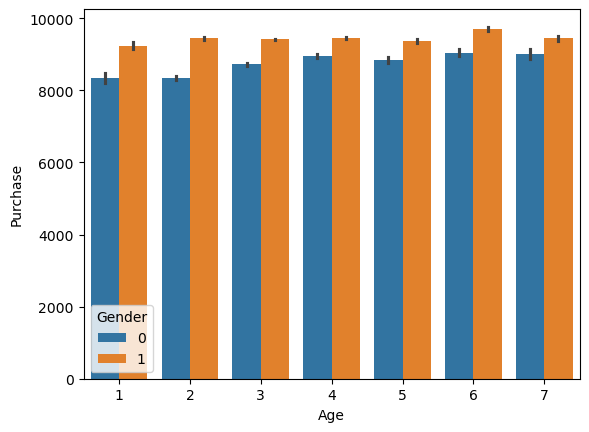

In [33]:
sns.barplot(x='Age',y='Purchase',hue='Gender',data=df)
plt.show()

## Insights
Purchase amount increases with age
* Younger age groups (0–17, 18–25) have lower average purchase
* Middle & higher age groups (36–45, 46–50, 51–55) show higher spending
* Indicates earning capacity increases purchasing power

Gender 1 consistently spends more than Gender 0 across all age groups
* Gap is visible in every age category
* Suggests gender is an important predictive feature

Trend is stable (no extreme variance)
* Purchase behavior is consistent across age bins
* Makes Age a reliable engineered feature

Purchase with Occupation

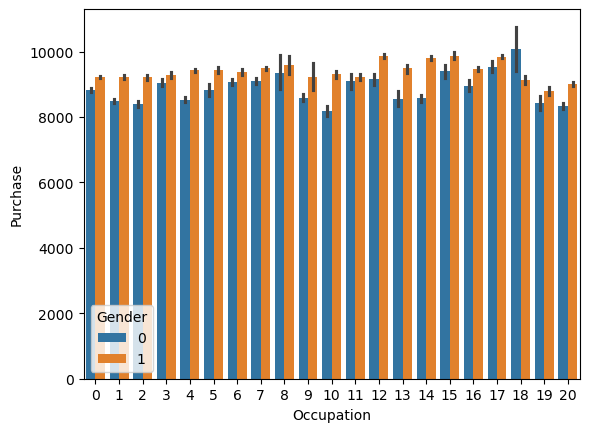

In [34]:
sns.barplot(x='Occupation',y='Purchase',hue='Gender',data=df)
plt.show()

## Insights
Purchase varies significantly across occupations
* Different occupation categories show different average purchase values
* Indicates occupation has predictive power and should be retained as a feature

Some occupations consistently show higher spending
* Occupation groups around the higher index values (e.g. ~14–18) show higher average purchases
* Suggests income / job nature influences purchase behavior

Gender-based trend remains consistent
* Across almost all occupations, Gender 1 spends more than Gender 0
* Confirms gender is a stable, strong feature across multiple segments

PRODUCT [1 ,2 ,3 ] v/s PURCHASE

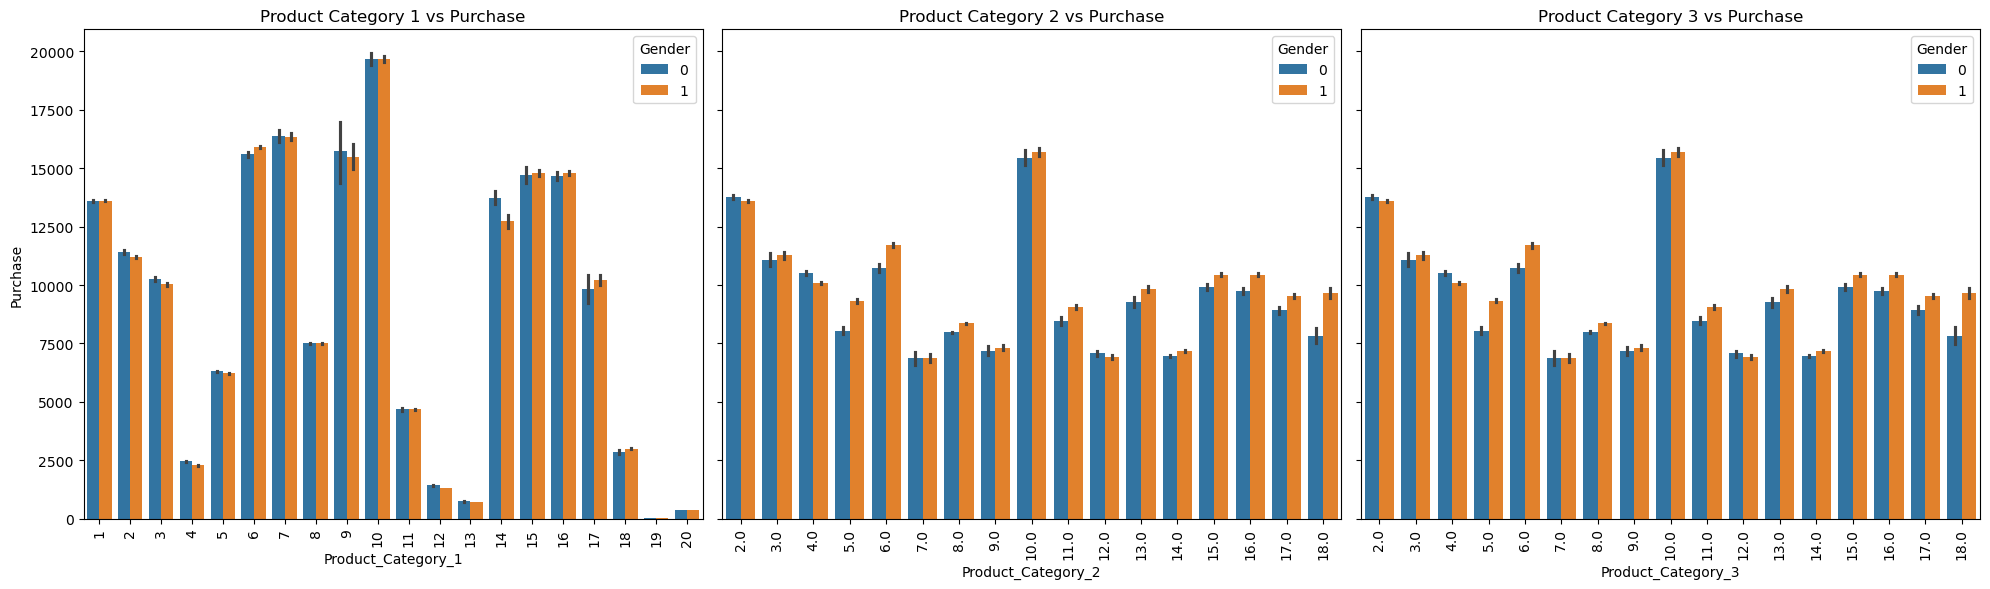

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
# Plot 1
sns.barplot(x='Product_Category_1',y='Purchase',hue='Gender',data=df,ax=axes[0])
axes[0].set_title('Product Category 1 vs Purchase')
axes[0].tick_params(axis='x', rotation=90)
# Plot 2
sns.barplot(x='Product_Category_2',y='Purchase',hue='Gender',data=df,ax=axes[1])
axes[1].set_title('Product Category 2 vs Purchase')
axes[1].tick_params(axis='x', rotation=90)
# Plot 3
sns.barplot( x='Product_Category_3',y='Purchase',hue='Gender',data=df,ax=axes[2])
axes[2].set_title('Product Category 3 vs Purchase')
axes[2].tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

### Insights

**Product Category 1 has the strongest influence on purchase amount**
   - Certain categories (e.g., categories around mid-range values) consistently show higher average purchase values.
   - This indicates that Product_Category_1 is a critical feature for predicting customer spending behavior.

**Purchase patterns are similar across genders**
   - Male and female customers exhibit very similar purchase trends across all product categories.
   - Gender alone does not appear to be a strong differentiating factor for purchase amount, suggesting limited standalone predictive power.

**Consistent purchasing behavior across categories**
   - Across Product_Category_1, 2, and 3, purchasing trends remain stable with no extreme volatility.
   - This consistency indicates reliable customer behavior patterns, which is beneficial for predictive modeling.

Overall, the analysis highlights that product-related features have a stronger impact on purchase behavior than demographic attributes such as gender.


## Feature Scaling

In [46]:
Df_test=df[df['Purchase'].isnull()]

In [56]:
Df_train=df[~df['Purchase'].isnull()]

In [57]:
X=Df_train.drop('Purchase',axis=1)

In [58]:
y=Df_train['Purchase']

In [59]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.33,random_state=42)

In [60]:
X_train.drop('Product_ID',axis=1,inplace=True)
X_test.drop('Product_ID',axis=1,inplace=True)

In [69]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

## BEFORE V/S AFTER

In [70]:
df.head(2)

,Product_ID,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,B,C
0,P00069042,0,1,10,2,0,3,8.0,8.0,8370.0,0,0
1,P00248942,0,1,10,2,0,1,6.0,6.0,15200.0,0,0


### V/S

In [71]:
df_raw=pd.read_csv('train.csv')
df_raw.head(2)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200


### Feature Engineering Highlights
* Transformed raw categorical and temporal data into model-ready numerical features, enabling effective machine learning training.
* Eliminated non-informative identifiers and handled missing values, reducing noise and improving generalization.
* Applied feature scaling to ensure balanced contribution across numerical variables.